In [1]:
import sys
if '/disks/cosmodm/vdvuurst' not in sys.path:
    sys.path.append('/disks/cosmodm/vdvuurst')

import numpy as np
import h5py
from matplotlib import pyplot as plt
import os
from importlib import reload
import json
import ONEHALO
from tqdm import tqdm
from functions import modified_logspace, BIC
from onehalo_plotter import *
from functional_forms import *
format_plot()

from scipy.optimize import minimize


### Testing initial conditions

In [ ]:
# init_method = 'L-BFGS-B'
init_method = 'Nelder-Mead'

MADD_test = ONEHALO.ONEHALO_MADD_fitter()


init_path = f'/disks/cosmodm/vdvuurst/data/onehalo_MADD_initial_conditions/{init_method}'
param_path = f'/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/MADD_subsample/{init_method}'
MADD_fitter = ONEHALO.ONEHALO_MADD_fitter()

for i, file in enumerate(os.listdir(init_path)):
    fp = os.path.join(init_path, file)

    params, MCMC_stepsizes = np.load(fp)
    combi_nr = int(file.split('_')[-1].strip('.npy'))
    print(combi_nr)
    function_combi = all_combis[combi_nr - 1]
    function_combi_names = all_names[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(function_combi)

    split_params = MADD_fitter.split_parameters(params, n_params_m)
    DG_params = MADD_fitter.get_double_gauss_parameters(split_params, function_combi, n_params_r)

    print(DG_params)
    print()
    if i == 50:
        break

3628
[[1.19580347e+03 4.30864655e+02 4.24624237e+02 ... 1.41607776e+03
  4.27450745e+02 1.97312256e+03]
 [4.48943237e+02 2.21007248e+02 1.94121094e+02 ... 5.48054199e+02
  3.14182312e+02 4.52853516e+02]
 [8.90278399e-01 9.91457924e-02 1.29279211e-01 ... 8.98091480e-01
  1.16888061e-01 8.88223484e-01]]

15306
[[2.00000000e+03 2.00000000e+03 2.00000000e+03 ... 2.00000000e+03
  2.00000000e+03 2.00000000e+03]
 [8.23474243e+02 2.73113708e+02 2.20566849e+02 ... 1.54076697e+03
  2.60407257e+02 1.62622034e+03]
 [9.82506482e-01 9.92837084e-01 9.67810620e-01 ... 9.93891072e-01
  9.71166702e-01 9.79987837e-01]]

4019
[[9.53602600e+02 3.89407654e+02 3.67809875e+02 ... 6.13586609e+02
  5.78377441e+02 1.28261438e+03]
 [4.50639191e+02 2.13590439e+02 2.90828796e+02 ... 4.70262085e+02
  3.86431702e+02 4.64179504e+02]
 [9.34023641e-01 4.13432829e-02 8.48393738e-02 ... 4.86749150e-02
  9.21449415e-01 9.29101102e-01]]

19458
[[4.03521576e+02 4.27093903e+02 4.23564911e+02 ... 4.25144287e+02
  4.23754608e+0

/disks/cosmodm/vdvuurst/ONEHALO.py:761: RuntimeWarning: overflow encountered in cast
  double_gauss_params[i, :] = param_values
/disks/cosmodm/vdvuurst/functional_forms.py:15: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-B * x) + C
/disks/cosmodm/vdvuurst/functional_forms.py:15: RuntimeWarning: overflow encountered in multiply
  return A * np.exp(-B * x) + C


### Loading in data and setting up for MCMC tests

In [3]:
with h5py.File('/disks/cosmodm/vdvuurst/data/Onehalo_M_12-15.5_subsampled.hdf5') as handle:
    rel_vels = handle['rel_vels'][:]
    halo_masses = handle['mass'][:]
    rel_dist = handle['rel_dist'][:]

##### Which combination has the best BIC score?

In [ ]:
def get_DG_from_combi_nr(combi_nr, param_dict, MADD_test = MADD_test):
    func_combi = all_combis[combi_nr - 1]
    func_combi_names = all_names[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(func_combi)
    params = np.array(param_dict['parameters'])
    split_params = MADD_test.split_parameters(params, n_params_m)
    DG = MADD_test.get_double_gauss_parameters(split_params, func_combi, n_params_r)
    return DG#, init_guess[:n_params_sigma_1]

bics = np.zeros(shape = len(os.listdir(param_path)))
combi_nrs = bics.copy().astype(int)
sigma_bounded = combi_nrs.copy().astype(bool)

for i,file in tqdm(enumerate(os.listdir(param_path)), total = len(os.listdir(param_path))):
    filepath = os.path.join(param_path, file)
    combi_nr = int(file.split('_')[-1].split('.')[0])
    
    with open(filepath) as f:
        param_dict = json.load(f)
    combi_nrs[i] = combi_nr
    bics[i] = param_dict['BIC']
    sigma_bounded[i] = np.all(get_DG_from_combi_nr(combi_nr, param_dict)[0] == 2000.)

argsort_bics = np.argsort(bics)
best_combi_nrs = combi_nrs[argsort_bics]
print('Best combi numbers', best_combi_nrs[:10])
print('Corresponding BIC scores:', bics[argsort_bics][:10])
print('Sigma is bounded for them:', sigma_bounded[argsort_bics][:10])

with open(f'/disks/cosmodm/vdvuurst/data/OneHalo_param_fits/MADD_subsample/Nelder-Mead/function_combi_{best_combi_nrs[0]}.json') as f:
    best_dict = json.load(f)

best_dict

100%|██████████| 2486/2486 [00:08<00:00, 290.34it/s]

Best combi numbers [ 4643 11495  4791  1686  8556 10618 11590  3819 15946 19121]
Corresponding BIC scores: [492172.15042682 492219.91929434 492241.12282225 492303.09934136
 492328.47042781 492381.06969256 492415.13719529 492450.77908365
 492460.6256298  492483.88111616]
Sigma is bounded for them: [False False  True  True False False False  True  True False]


{'parameters': [-2.5744139052126735,
  3.565338456403039,
  7.363283521964385,
  -3.9931921495628733,
  1.2712879663661505,
  -11.641510538583919,
  6.412440604281398,
  -2.3835135387289315,
  9.129305636860922,
  -0.9671519862725798,
  82.79266610969098,
  1.6621097217168694,
  -4.801123792387245,
  4.436637821486581,
  -1.8400249751845448,
  1.2527876549505657,
  -0.28706287450112583,
  460.8650199053816,
  0.010349594495297371,
  -0.010369686650249295,
  -0.01423894806036825,
  -0.011609991838382207,
  0.05538997025808713,
  -0.057822376227856694],
 'likelihood': 245960.70908712846,
 'BIC': 492172.15042681503,
 'functional_form': [['poly_3',
   ['linear', 'parabola', 'parabola', 'exponential']],
  ['parabola', ['linear', 'linear', 'exponential']],
  ['inverse', ['exponential', 'parabola']]],
 'nwalkers': 60,
 'nsteps': 1000,
 'initial_condition_method': 'Nelder-Mead'}

Best BIC: 4643 492172.15042681503


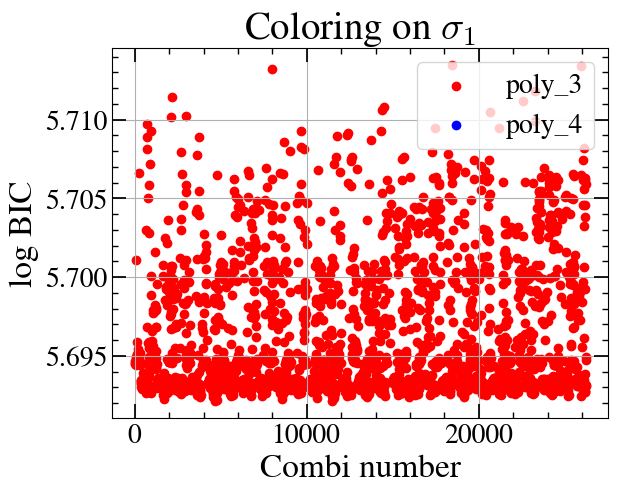

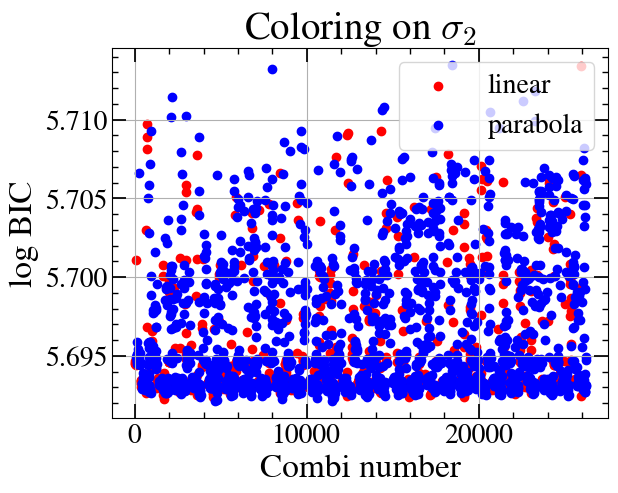

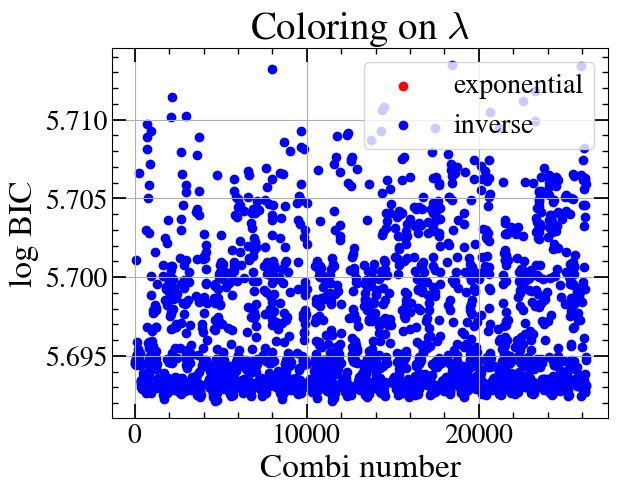

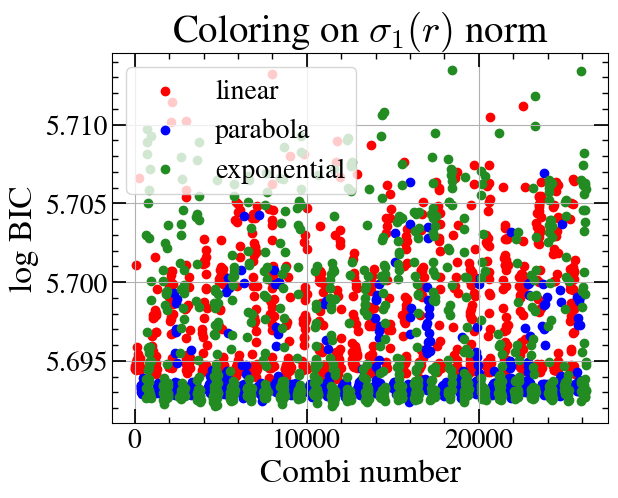

In [6]:
bics = np.empty(shape = len(os.listdir(param_path)))

colors = ['red', 'blue', 'forestgreen', 'magenta', 'purple', 'black']
labels = ['poly_4_sigma_1', 'poly_3_sigma_1', 'linear_sigma_2', 'parabola_sigma_2', 'exp_lambda', 'inv_lambda']


combi_nrs = np.zeros_like(bics, dtype = int)
s1_colors = []
s2_colors = []
lam_colors = []
s1_norm_colors = []
labels = []

for i,file in enumerate(os.listdir(param_path)):
    filepath = os.path.join(param_path, file)
    with open(filepath) as f:
        param_dict = json.load(f)
    bics[i] = param_dict['BIC']
    combi_nr = int(file.split('_')[-1].strip('.json'))
    combi_nrs[i] = combi_nr

    func_names = param_dict['functional_form']
    s1, s2, l = func_names

    match s1[0]:
        case 'poly_3':
            s1_colors.append('red')
        case 'poly_4':
            s1_colors.append('blue')
    
    match s2[0]:
        case 'linear':
            s2_colors.append('red')
        case 'parabola':
            s2_colors.append('blue')
    
    match l[0]:
        case 'exponential':
            lam_colors.append('red')
        case 'inverse':
            lam_colors.append('blue')

    match s1[1][-1]:
        case 'linear':
            s1_norm_colors.append('red')
        case 'parabola':
            s1_norm_colors.append('blue')
        case 'exponential':
            s1_norm_colors.append('forestgreen')
    
bestarg = np.nanargmin(bics)
best_combi_nrs = combi_nrs[np.argsort(bics)]
print('Best BIC:', combi_nrs[bestarg], bics[bestarg])

# coloring on sigma_1
cmask = np.array(s1_colors) == 'red'
plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'poly_3')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'poly_4')
ax = plt.gca()
ax.set_title(r'Coloring on $\sigma_1$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    
# coloring on sigma 2
cmask = np.array(s2_colors) == 'red'
plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'linear')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'parabola')
ax = plt.gca()
ax.set_title(r'Coloring on $\sigma_2$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    
#coloring on lambda
cmask = np.array(lam_colors) == 'red'

plt.figure()
plt.scatter(combi_nrs[cmask], np.log10(bics[cmask]), c = 'red', label = 'exponential')
plt.scatter(combi_nrs[np.invert(cmask)], np.log10(bics[np.invert(cmask)]), c = 'blue', label = 'inverse')
ax = plt.gca()
ax.set_title(r'Coloring on $\lambda$')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()

# coloring on sigma 1(r) norm
plt.figure()
rmask = np.array(s1_norm_colors) == 'red'
bmask = np.array(s1_norm_colors) == 'blue'
gmask = np.array(s1_norm_colors) == 'forestgreen'

plt.scatter(combi_nrs[rmask], np.log10(bics[rmask]), c = 'red', label = 'linear')
plt.scatter(combi_nrs[bmask], np.log10(bics[bmask]), c = 'blue', label = 'parabola')
plt.scatter(combi_nrs[gmask], np.log10(bics[gmask]), c = 'forestgreen', label = 'exponential')

ax = plt.gca()
ax.set_title(r'Coloring on $\sigma_1(r)$ norm')
ax.set(ylabel ='log BIC', xlabel = 'Combi number')
ax.grid()
ax.legend()
plt.show()
    



In [ ]:


def get_init_DG_from_combi_nr(combi_nr):
    func_combi = all_combis[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(func_combi)

    with open(f'{param_path}/function_combi_{combi_nr}.json') as f:
        param_dict = json.load(f)
    
    params = np.load(f'/disks/cosmodm/vdvuurst/data/onehalo_MADD_initial_conditions/Nelder-Mead/function_combi_{combi_nr}.npy')[0]
    split_params = MADD_test.split_parameters(params, n_params_m)
    DG = MADD_test.get_double_gauss_parameters(split_params, func_combi, n_params_r)

    return DG

print(best_combi_nrs[0])
get_init_DG_from_combi_nr(best_combi_nrs[0])

# for combi_nr in combi_nrs:
#     DG = getinit

4643


array([[6.01401367e+02, 4.73889282e+02, 4.72668610e+02, ...,
        4.92843384e+02, 4.77056580e+02, 8.09006775e+02],
       [4.84966858e+02, 1.64135223e+02, 1.93406921e+02, ...,
        4.45009979e+02, 3.51694336e+02, 4.87663116e+02],
       [1.02372852e-03, 9.98872623e-01, 9.95646189e-01, ...,
        9.99573163e-01, 9.97689913e-01, 1.02305156e-03]], shape=(3, 34447))

(3, 34447)


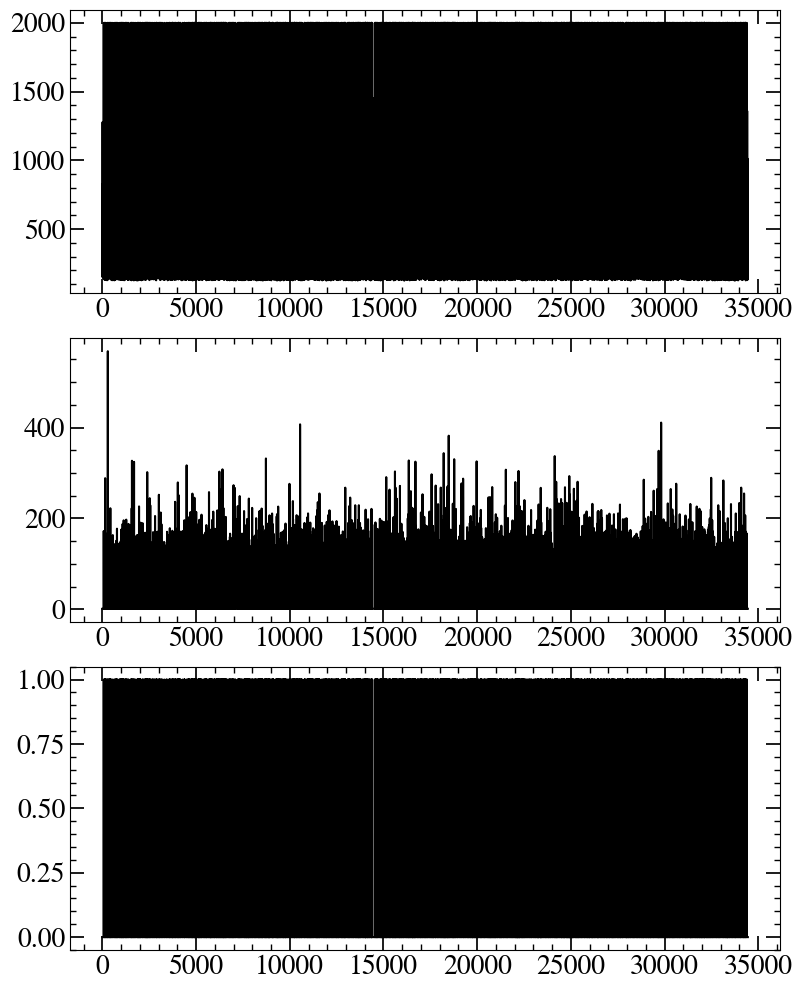

In [ ]:
def get_DG_from_combi_nr(combi_nr):
    func_combi = all_combis[combi_nr - 1]
    n_params_r, n_params_m, ntot = ONEHALO.param_info(func_combi)

    with open(f'{param_path}/function_combi_{combi_nr}.json') as f:
        param_dict = json.load(f)
    
    params = np.array(param_dict['parameters'])
    split_params = MADD_test.split_parameters(params, n_params_m)
    DG = MADD_test.get_double_gauss_parameters(split_params, func_combi, n_params_r)

    return DG, param_dict['BIC']

# for combi_nr in best_combi_nrs: # sorted from lowest BIC to highest
#     DG_i, BICi = get_DG_from_combi_nr(combi_nr)
#     print(combi_nr, f'BIC = {BICi}', DG_i[2].nonzero(), (DG_i[2] - 1.).nonzero())

DG_best, _ = get_DG_from_combi_nr(best_combi_nrs[5])
print(DG_best.shape)
fig, axes = plt.subplots(nrows = 3, figsize = (8, 10))
for i, ax in enumerate(axes):
    ax.plot(DG_best[i,:], color = 'black')
fig.tight_layout()
plt.show()

In [9]:
# dictionary that, given a function in r, knows what to set the parameters to for a decent starting position
r_function_dict = {'poly_4':[0,0,0,0,500], 'poly_3':[0,0,0,500], 
                    'parabola':[0,0,50], 'linear':[0, 50], 'exponential':[0,0,0.25], 'inverse':[0,0.25]} 

# Amount of parameters each function type takes
m_func_n_params_dict = {'linear': 2, 'parabola': 3, 'exponential': 3}
def _init_conditions(combi_names: list):
    """ Generate simplistic initial conditions based on values specified in the variables r_function_dict. 

    Args:
        combi_names (list): Array-like of structured function names of desired funtction combination. Should be as generated in the functional_forms.py script and of only 1 function combination.

    Returns:
        list: simple initial conditions for the given function combination.
    """
    initial_conditions = []
    for rfunc, mfuncs in combi_names:
        for rparam_value, mfunc in zip(r_function_dict[rfunc], mfuncs):
            if rparam_value == 0:
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc])]
            else: 
                mfunc_values = [0 for _ in range(m_func_n_params_dict[mfunc] - 1)]
                mfunc_values.append(rparam_value) 

            initial_conditions.extend(mfunc_values)
    
    return initial_conditions

In [ ]:
reload(ONEHALO)
# from ONEHALO import _init_conditions

from warnings import filterwarnings
# this might be a liiiitle dangerous but cleans up the output by a lot. that's because we often see invalid values in log10, but that's ok
filterwarnings('ignore',category = RuntimeWarning)

combi_nr = best_combi_nrs[0]    # not an index
test_func_combi = all_combis[combi_nr - 1]
test_func_combi_names = all_names[combi_nr - 1]
with open(f'{param_path}/function_combi_{combi_nr}.json') as f:
    param_dict = json.load(f)
BIC_score = param_dict['BIC']

init_guess, MCMC_scales = np.load(f'{init_path}/function_combi_{combi_nr}.npy')
MCMC_scales = MCMC_scales[:, np.newaxis]
simple = _init_conditions(test_func_combi_names)

print(ONEHALO.param_info(test_func_combi))

nwalkers = 35
nsteps = 500
n_params_r, n_params_m, ntot = ONEHALO.param_info(test_func_combi)

# MADD_test.fit_function_combi_to_data(test_func_combi, test_func_combi_names, combi_nr, nwalkers,
#                                       nsteps, verbose = True, plot = True)

with open(f'{param_path}/function_combi_{combi_nr}.json') as f:
    param_dict = json.load(f)

params = np.array(param_dict['parameters'])

split_params = MADD_test.split_parameters(params, n_params_m)
DG = MADD_test.get_double_gauss_parameters(split_params, test_func_combi, n_params_r)
DG

([4, 3, 2], [2, 3, 3, 3, 2, 2, 3, 3, 3], 24)


array([[578.35943604, 468.17468262, 465.00158691, ..., 489.48419189,
        468.1461792 , 769.08441162],
       [475.88973999, 164.37678528, 200.82250977, ..., 431.33013916,
        354.27359009, 477.29983521],
       [  0.        ,   0.99874587,   1.        , ...,   1.        ,
          1.        ,   0.        ]], shape=(3, 34447))

### Important diagnostics on the results

In [12]:
# sigma1 and sigma2 move only *very* slightly while lambda, on average, goes outside of prior range
print(DG[0].mean(), np.std(DG[0]))
print(DG[1].mean(), np.std(DG[1]))
print(DG[2].mean(), np.std(DG[2]))
print()

prior_mask = np.isfinite(log_prior_vec(DG))
print(f'{prior_mask.sum()} points pass the prior')
try: 
    print(halo_masses[np.invert(prior_mask)].min(), halo_masses[np.invert(prior_mask)].max()) # sometimes, only part of mass space gets through the prior
    print(rel_dist[np.invert(prior_mask)].min(), rel_dist[np.invert(prior_mask)].max()) # all of radial space gets through
except:
    pass

# Note how, within prior range, the only significant change is in the lambda parameter. what does this mean?
print()
print(DG[0, prior_mask].mean(), np.std(DG[0, prior_mask]))
print(DG[1, prior_mask].mean(), np.std(DG[1, prior_mask]))
print(DG[2, prior_mask].mean(), np.std(DG[2, prior_mask]))


535.4489213039446 164.20214936653258
302.3453134932144 127.69919945584867
0.7590876757534973 0.4268688835313864

34447 points pass the prior

535.4489213039446 164.20214936653258
302.3453134932144 127.69919945584867
0.7590876757534973 0.4268688835313864


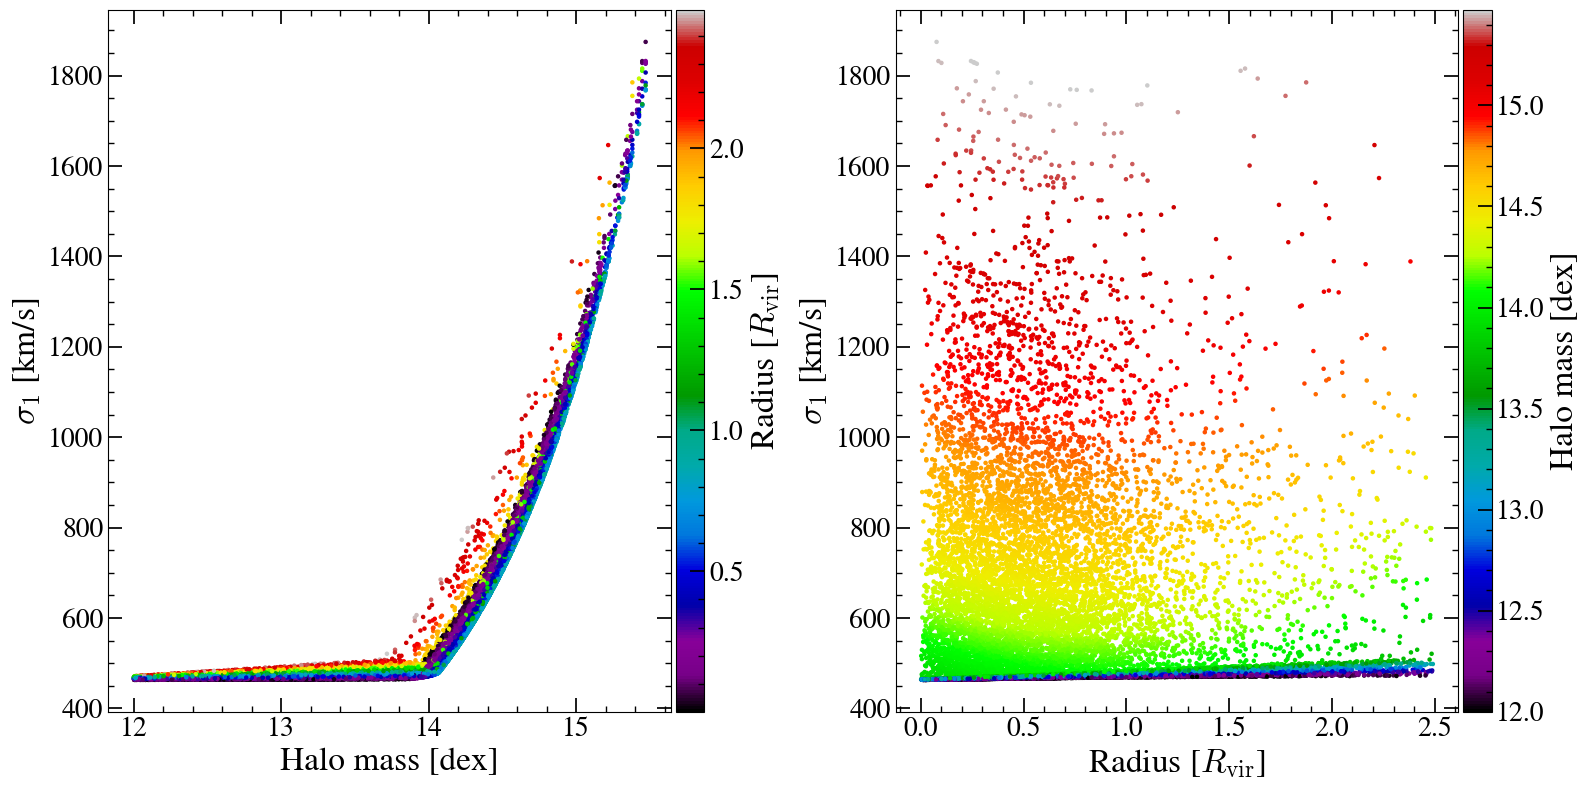

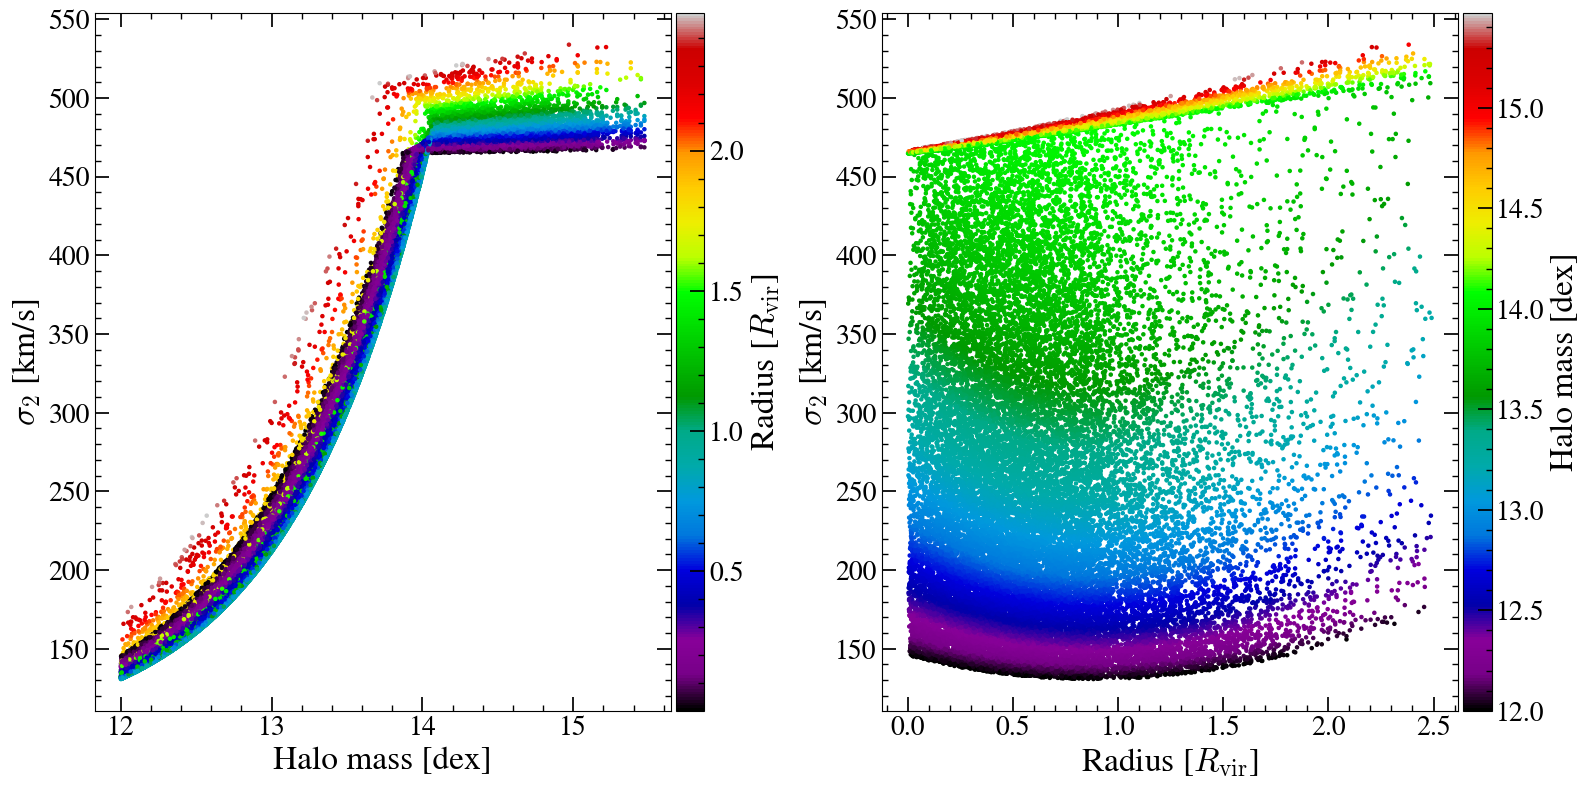

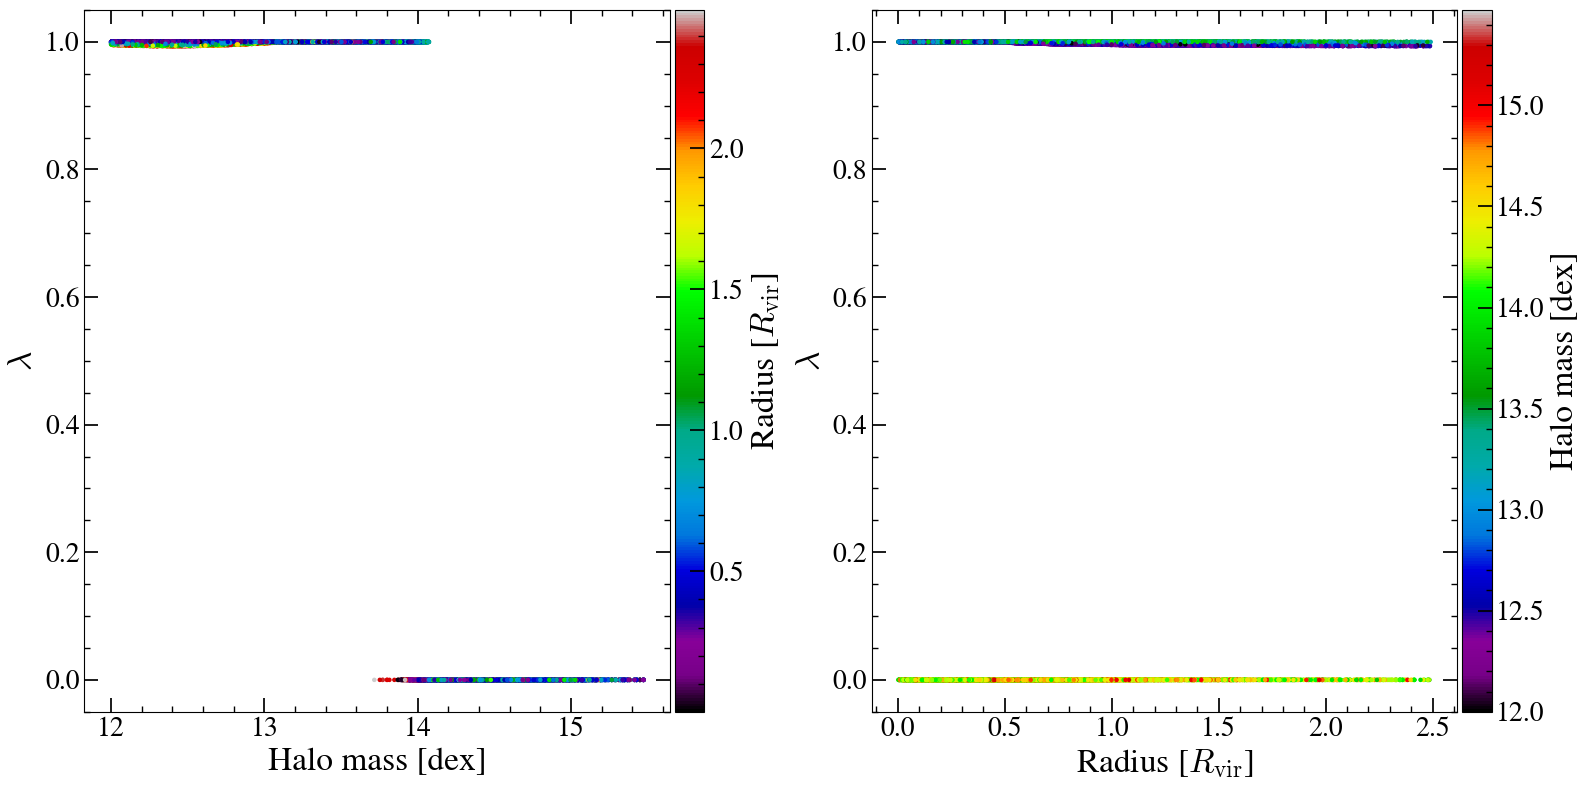

In [15]:
from mpl_toolkits.axes_grid1 import make_axes_locatable 

# Define this function, based on code from the first few weeks, to add a nice colobar scaled to the image
def add_pretty_colorbar(im: mpl.image.AxesImage , ax: plt.Axes, fig: plt.Figure, label = ''):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig.colorbar(im, cax=cax, label = label)

def plot_DG_param_mass_rad(param_idx: int):
    yaxes = [r'$\sigma_1$ [km/s]', r'$\sigma_2$ [km/s]', r'$\lambda$']
    fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (16, 8), sharey=False)
    # fig.suptitle(suptitles[param_idx], fontsize = 30)
    mass_scat = ax1.scatter(halo_masses+10, DG[param_idx], c = rel_dist, cmap = 'nipy_spectral', s = 5)
    add_pretty_colorbar(mass_scat, ax1, fig, r'Radius [$R_{\mathrm{vir}}$]')

    rad_scat = ax2.scatter(rel_dist, DG[param_idx], c = halo_masses+10, cmap = 'nipy_spectral', s = 5)
    add_pretty_colorbar(rad_scat, ax2, fig, 'Halo mass [dex]')

    ax1.set(ylabel = yaxes[param_idx], xlabel = 'Halo mass [dex]')
    ax2.set(ylabel = yaxes[param_idx], xlabel = r'Radius [$R_{\mathrm{vir}}$]')
    fig.tight_layout()
    plt.show()

plot_DG_param_mass_rad(0)
plot_DG_param_mass_rad(1)
plot_DG_param_mass_rad(2)

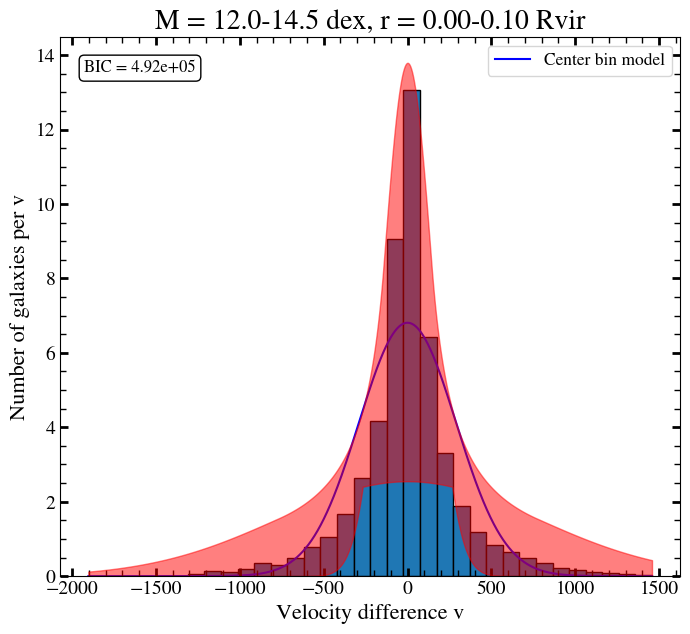

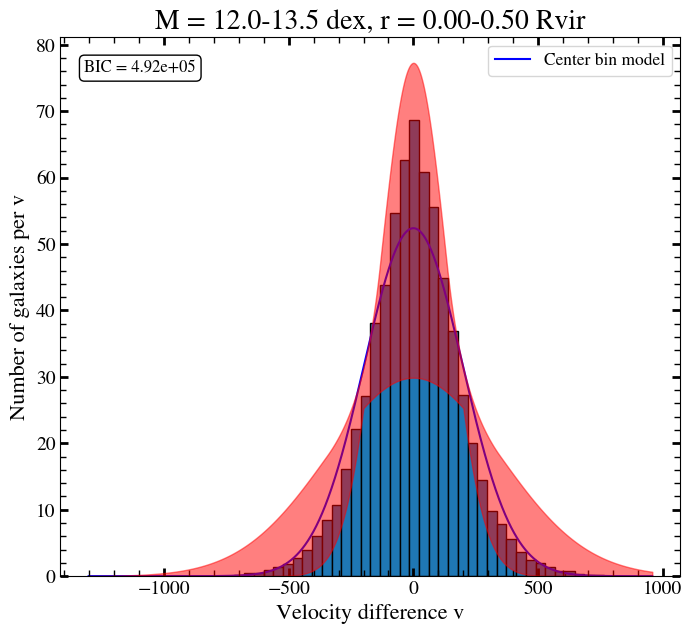

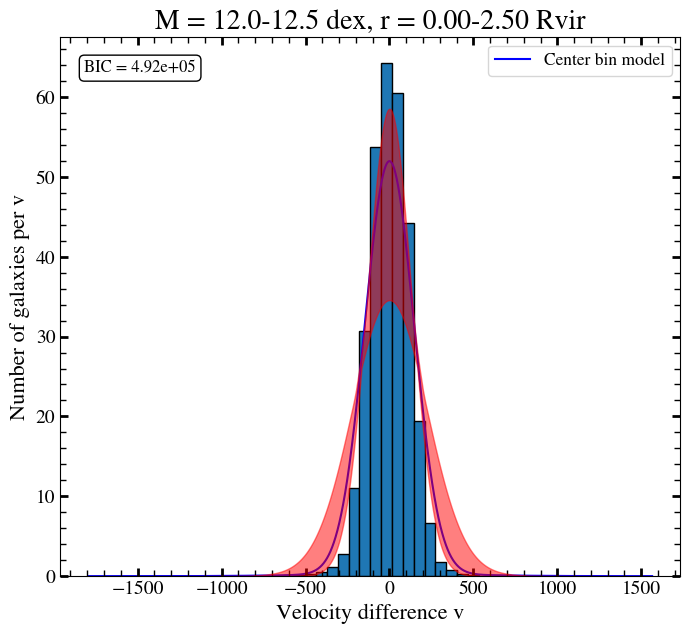

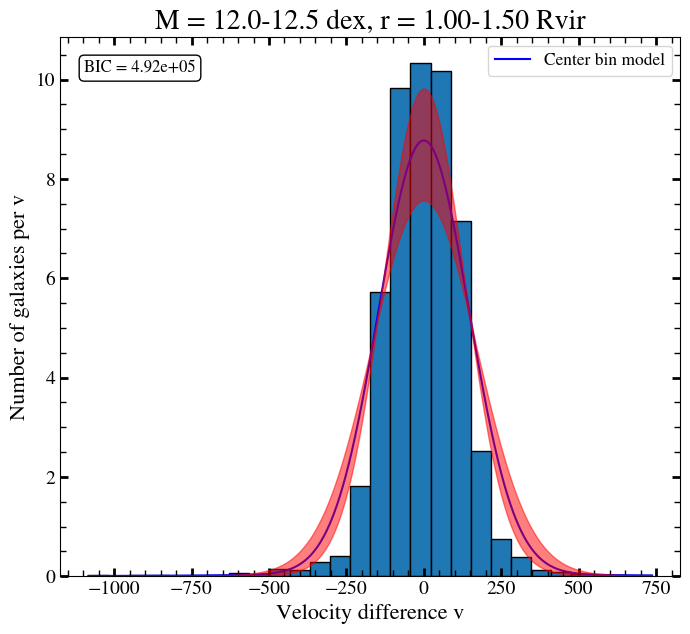

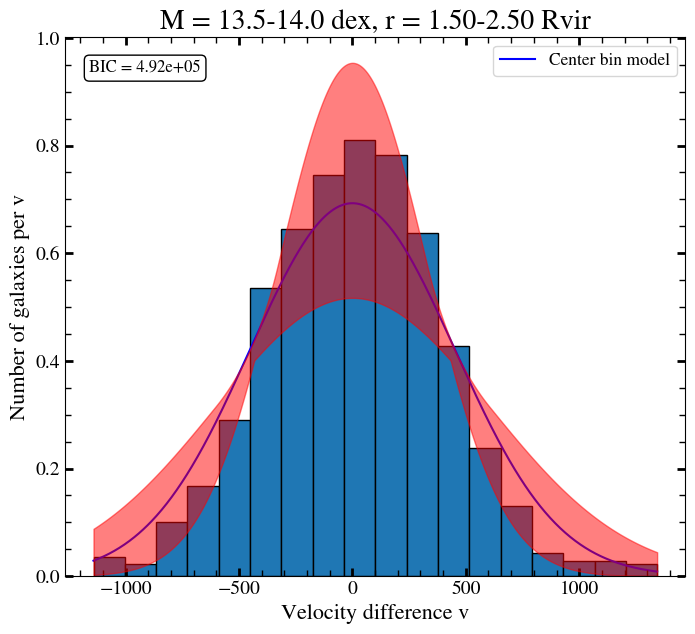

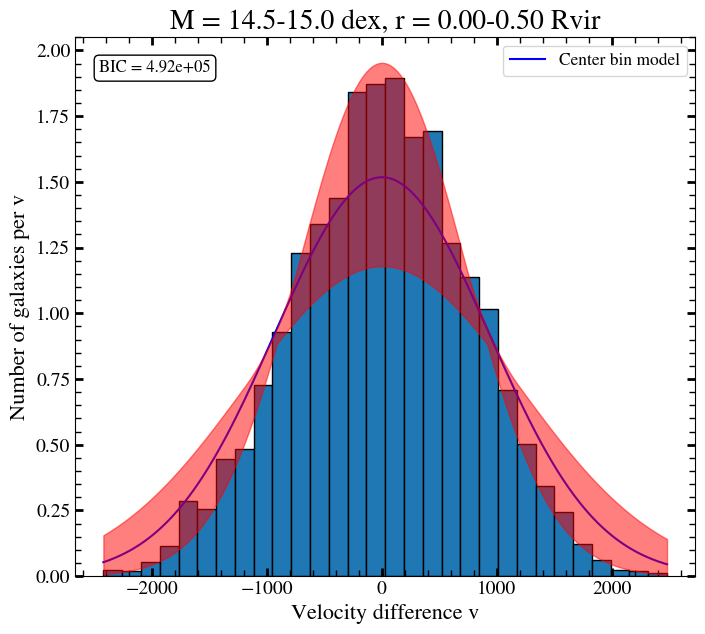

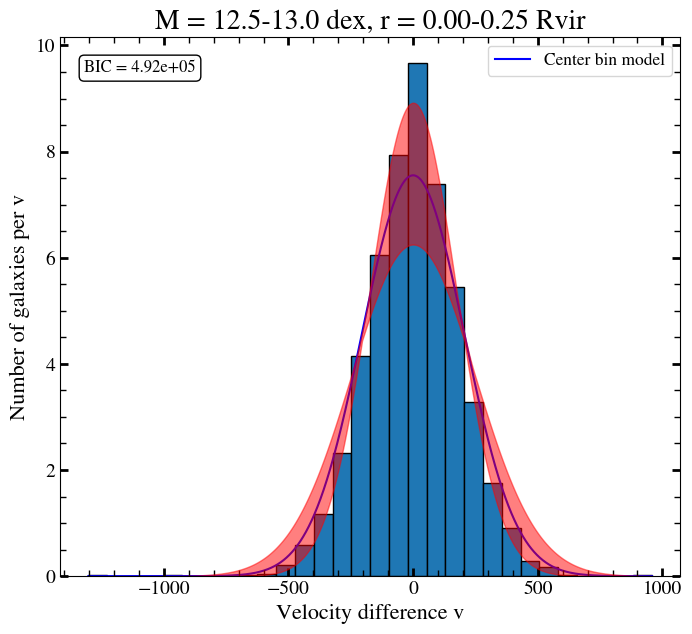

In [ ]:
prior_mask = log_prior_vec(DG) == 0

def plot_in_bin(best_params: np.ndarray, function_combi: list, combi_number: int,
                n_params_r: int, n_params_m: list,
                BIC_score: np.float32, mbin: list | tuple, rbin: list | tuple, show: bool = False,
                filepath: str = '/disks/cosmodm/vdvuurst/figures/onehalo_MADD/subsampled') -> None:
    
        halo_masses_prior = halo_masses[prior_mask]
        rel_dist_prior = rel_dist[prior_mask]

        # Define the bin
        mbin_mask = ONEHALO._make_mass_mask(halo_masses_prior, *mbin, logmass = True)
        rbin_mask = ONEHALO._make_radial_mask(rel_dist_prior, *rbin)
        bin_mask = np.logical_and(mbin_mask, rbin_mask)

        # Get binned data
        vel_data_in_bin = rel_vels[prior_mask][bin_mask].flatten() # first apply mask to all 3-vectors, then flatten
        min_half_v_sq_in_bin = MADD_test.min_half_v_sq_arr[prior_mask][bin_mask]
        masses_in_bin = halo_masses_prior[bin_mask]
        rel_dist_in_bin = rel_dist_prior[bin_mask]

        bins = rice_bins(vel_data_in_bin.size)
        filename = os.path.join(filepath, f'function_combi_{combi_number}')
        mkdir_if_non_existent(filename)
        filename = os.path.join(filename, f'{ONEHALO.str_from_mbin(mbin)}_{ONEHALO.str_from_rbin(rbin)}_fit.png')

        DG_params = MADD_test.get_double_gauss_parameters(MADD_test.split_parameters(best_params, n_params_m), function_combi,
                                                        n_params_r, masses_in_bin, rel_dist_in_bin)


        # Plotting
        fig, ax = plt.subplots(figsize = (8,7))
        ax.set_xlabel('Velocity difference v', fontsize=16)
        ax.set_ylabel('Number of galaxies per v', fontsize=16)
        ax.tick_params(axis='both', which='major',length=6, width=2,labelsize=14)

        # Bin velocity histogram and plot it
        bin_heights, bin_edges = np.histogram(vel_data_in_bin, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        bin_width= bin_edges[1] - bin_edges[0] 
        bin_widths = np.diff(bin_edges)  # The width of each bin
        number_density = bin_heights / bin_widths  # Normalize by bin width
        hist_area=np.sum(bin_heights)
        ax.bar(bin_centers, number_density, width=bin_width, align='center', edgecolor = 'black')

        # Add BIC score in textbox
        ax.text(0.155, 0.83, f'BIC = {BIC_score:.2e}', transform=plt.gcf().transFigure,
                backgroundcolor='white',zorder=-1,
                bbox = {'boxstyle':'round','facecolor':'white'}, fontsize = 12)


        DAT = np.linspace(np.min(vel_data_in_bin),np.max(vel_data_in_bin), min_half_v_sq_in_bin.size)

        ax_func = lambda x: hist_area * double_gaussian(DAT, *x).flatten()
        all_models = np.apply_along_axis(ax_func, 0, DG_params)
        # print(all_models.shape, DAT.shape)
        min_model_at_point = np.min(all_models, axis = 1)
        max_model_at_point = np.max(all_models, axis = 1)

        # plot_data = np.median(all_models, axis = 1)

        # ax.plot(DAT.flatten(), plot_data.flatten(), '-', label = f"Double Gaussian (MADD)\nN={hist_area:.0f}, N" + r'$_\mathrm{b}$' + f" = {bins}",
        #         color='red', zorder = 1)
        ax.fill_between(DAT.flatten(), min_model_at_point, max_model_at_point, alpha = 0.5, color = 'red', zorder = 2)


        # To plot every 100th model

        # for i, model in enumerate(all_models.T[::100]):
        #         params = np.round(DG_params[:, ::100][:,i], 1)
        #         if params[-1] == 1:
        #                 label = r'$\sigma$' + f' = {params[1]}'
        #         elif params[-1] == 0:
        #                 label =  r'$\sigma$' + f' = {params[0]}'
        #         else:
        #                 label = r'$\sigma_1$ '+ f'= {params[0]},' + r'$\sigma_2$' + f' = {params[1]}'

        #         ax.plot(DAT.flatten(), model.flatten(), '--', zorder = 11, label = label)#, c = colors[i], cmap = 'nipy_spectral')

        
        # Plot the model corresponding to the center of the bin
        center_bin_mass, center_bin_rad = np.mean(mbin), np.mean(rbin)

        DG_center = MADD_test.get_double_gauss_parameters(MADD_test.split_parameters(best_params, n_params_m), function_combi,
                                                        n_params_r, center_bin_mass, center_bin_rad)
        
        ax.plot(DAT.flatten(), ax_func(DG_center), label = 'Center bin model', color = 'blue', zorder = 1, lw = 1.5)

        ax.legend(fontsize=12.5, loc="upper right")
        ax.set_title(f'{ONEHALO.str_from_mbin(mbin).replace('_',' = ')} dex, {ONEHALO.str_from_rbin(rbin).replace('_',' = ')} Rvir', fontsize = 20)

        if not show:
                fig.savefig(filename, dpi=200)
                plt.close()
        else:
                plt.show()


plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 4.5], [0.00, 0.10], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 3.5], [0.00, 0.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 2.5], [0.00, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.0, 2.5], [1., 1.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [3.5, 4.0], [1.5, 2.5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [4.5, 5.0], [0, .5], show = True)
plot_in_bin(param_dict['parameters'], test_func_combi, combi_nr, n_params_r, n_params_m, BIC_score, [2.5, 3.0], [0.00, 0.25], show = True)

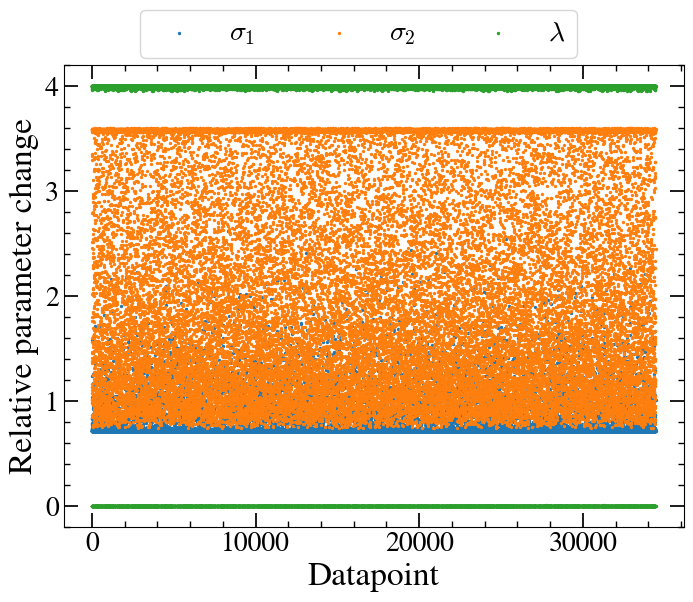

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))

s1, s2, lam = DG
s1_change = s1 / 750.
s2_change = s2 / 150.
lam_change = lam / 0.25

xvals = np.arange(s1.shape[0])
ax.scatter(xvals, s1_change, s = 2, label = r'$\sigma_1$')
ax.scatter(xvals, s2_change, s = 2, label = r'$\sigma_2$')
ax.scatter(xvals, lam_change, s = 2, label = r'$\lambda$')
ax.legend(bbox_to_anchor = (0.85, 1.15), ncols = 3)
ax.set(ylabel = 'Relative parameter change', xlabel = 'Datapoint')

plt.show()